# Model predictions

Applies the trained classifier to every site-month, writes per-pixel class rasters, and
aggregates them into the per-waterhole composition time series the project exists to produce.

**Outputs**

| file | what it is |
|---|---|
| `predictions/pixel_predictions/site_XXX/*_pred.tif` | uint8 class raster on the source tile's exact grid |
| `..._conf.tif` | prediction confidence, 0-100 |
| `..._pred.png` | the same classes colourised, for display |
| `..._/bounds.json` | WGS84 bounds, written once per site |
| `predictions/waterhole_composition.csv` | one row per site-month: counts and fractions per class |
| `predictions/waterhole_boxes.geojson` | all 187 boxes, for the dashboard map |
| `predictions/class_colours.json` | the class scheme, so a legend cannot drift from it |

The PNG and `bounds.json` exist so a browser can place predictions on a map as an image
overlay with no tile server and no backend — see `dashboard_plan.md`.

In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == "cookie-cutting" else Path.cwd() / "cookie-cutting"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import wh_bbox
import wh_config
import wh_features
import wh_inventory
import wh_plots
import wh_predict
import wh_train

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

cfg = wh_config.load()
manifest = wh_inventory.load_manifest(cfg)
print("config", cfg.source_path.name, "hash", cfg.hash)
print(f"{len(manifest):,} chips, {manifest['site_id'].nunique()} sites, "
      f"{manifest['year_month'].nunique()} months")

config waterhole_seg_config.yaml hash afde19a3ff27
15,708 chips, 187 sites, 84 months


## Parameters

In [2]:
PARAMS = wh_predict.PredictParams(
    model_name="classifier",          # from derived/models/

    # 3x3 majority filter, OFF. Standard despeckling for landscape classification
    # and wrong at this scale: 39% of the water patches here are 1-2 px and the
    # filter deletes them. Set to 3 if a site looks noisy and you want it.
    majority_filter_px=0,

    # Confidence band: max class probability as uint8 0-100. Costs about 60% of
    # the run time (predict_proba is the expensive call) and gives the dashboard
    # an uncertainty layer. Set False for a much faster run.
    write_confidence=False,

    # Colourised PNG beside each GeoTIFF. A browser cannot draw a GeoTIFF without
    # a tile server; it can place a PNG given bounds.
    write_png=True,

    # Which region the plots below summarise. BOTH bbox and footprint counts are
    # always written to the CSV, so switching this needs no re-run.
    denominator="bbox",

    # Flags an isolated wet month sitting between dry ones on a thin median.
    # It flags and never rewrites: it might be a compositing artefact, or it
    # might be the rainfall event you are looking for.
    flag_isolated_wet=True,
    low_obs_threshold=2.0,

    sites=None,        # None = all 187, or a tuple like ("025", "002")
    overwrite=False,   # False skips sites whose rasters already exist
    workers=6,         # sites are independent; 6 workers ~ 65 min for the archive
)

PARAMS

PredictParams(model_name='classifier', majority_filter_px=0, write_confidence=False, write_png=True, denominator='bbox', flag_isolated_wet=True, low_obs_threshold=2.0, wet_classes=('open_water', 'turbid_water'), good_mean_obs=3.0, poor_gap_fraction=0.5, sites=None, overwrite=False, workers=6)

## Check what the model actually is

The manifest is the authority on how this model must be applied. A model given features in a
different order does not fail — it returns confident nonsense — so the feature definition is
rebuilt from the manifest rather than from anything in this notebook.

In [3]:
model, meta = wh_train.load_model(cfg, PARAMS.model_name)
wh_predict.check_scheme(meta, cfg)

print(f"model      : {meta['model_class']}")
print(f"trained    : {meta['timestamp']}")
print(f"features   : {meta['n_features']}")
print(f"CV         : {meta['cv_macro_f1']:.3f} macro F1 ({meta['cv_strategy']})")
print(f"labels     : {meta['n_training_pixels']:,} px over {len(meta['training_sites'])} sites")

feature_params = wh_predict.feature_params_from_manifest(meta)
print(f"\nembeddings : {feature_params.use_alphaearth} "
      f"bands={feature_params.alphaearth_bands or 'all 64'}")
print(f"n_obs      : {feature_params.include_n_obs}")

model      : HistGradientBoostingClassifier
trained    : 2026-08-20T07:01:31+00:00
features   : 59
CV         : 0.856 macro F1 (group_kfold_by_site)
labels     : 95,370 px over 27 sites

embeddings : True bands=('A28', 'A32', 'A63')
n_obs      : False


**The model was trained on a subset of the sites and is about to be applied to all of
them.** Waterholes unlike anything labelled will still receive a confident-looking answer.
`mean_confidence` in the CSV, and the `_conf.tif` rasters, are what make that visible —
check them before trusting a site you never labelled.

## Dry run on one site

Predict a single site and look at it before committing an hour to the archive.

In [4]:
DRY_RUN_SITE = "025"

boxes = wh_bbox.load_boxes(cfg)
records = wh_predict.predict_site(
    manifest, cfg, model, meta, PARAMS, DRY_RUN_SITE, boxes
)
preview = pd.DataFrame(records)
print(f"{len(preview)} months predicted for site {DRY_RUN_SITE}")
preview[["year_month", "bbox_n_classified", "n_pixels_footprint",
         "mean_confidence", "gap_fraction"]].head()

84 months predicted for site 025


,year_month,bbox_n_classified,n_pixels_footprint,mean_confidence,gap_fraction
0,2019-01,4620,1011,NaN,0.001413
1,2019-02,4620,1011,NaN,0.001413
2,2019-03,4620,1011,NaN,0.001413
3,2019-04,4620,1011,NaN,0.001413
4,2019-05,4620,1011,NaN,0.001413


In [5]:
preview

,site_id,year_month,year,month,n_pixels_tile,n_pixels_bbox,n_pixels_footprint,has_footprint,footprint_area_ha,gap_fraction,...,footprint_frac_surrounding_vegetation,label,center_lon,center_lat,lon_min,lon_max,lat_min,lat_max,bbox_width_m,bbox_height_m
0,025,2019-01,2019,1,22650,4620,1011,True,10.11,0.001413,...,0.123640,WH_swamp,134.494391,-13.507006,134.491799,134.496983,-13.508751,-13.50526,561.127545,385.933345
1,025,2019-02,2019,2,22650,4620,1011,True,10.11,0.001413,...,0.139466,WH_swamp,134.494391,-13.507006,134.491799,134.496983,-13.508751,-13.50526,561.127545,385.933345
2,025,2019-03,2019,3,22650,4620,1011,True,10.11,0.001413,...,0.156281,WH_swamp,134.494391,-13.507006,134.491799,134.496983,-13.508751,-13.50526,561.127545,385.933345
3,025,2019-04,2019,4,22650,4620,1011,True,10.11,0.001413,...,0.177052,WH_swamp,134.494391,-13.507006,134.491799,134.496983,-13.508751,-13.50526,561.127545,385.933345
4,025,2019-05,2019,5,22650,4620,1011,True,10.11,0.001413,...,0.159248,WH_swamp,134.494391,-13.507006,134.491799,134.496983,-13.508751,-13.50526,561.127545,385.933345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,025,2025-08,2025,8,22650,4620,1011,True,10.11,0.001413,...,0.076162,WH_swamp,134.494391,-13.507006,134.491799,134.496983,-13.508751,-13.50526,561.127545,385.933345
80,025,2025-09,2025,9,22650,4620,1011,True,10.11,0.001413,...,0.074184,WH_swamp,134.494391,-13.507006,134.491799,134.496983,-13.508751,-13.50526,561.127545,385.933345
81,025,2025-10,2025,10,22650,4620,1011,True,10.11,0.001413,...,0.077151,WH_swamp,134.494391,-13.507006,134.491799,134.496983,-13.508751,-13.50526,561.127545,385.933345
82,025,2025-11,2025,11,22650,4620,1011,True,10.11,0.001413,...,0.139466,WH_swamp,134.494391,-13.507006,134.491799,134.496983,-13.508751,-13.50526,561.127545,385.933345


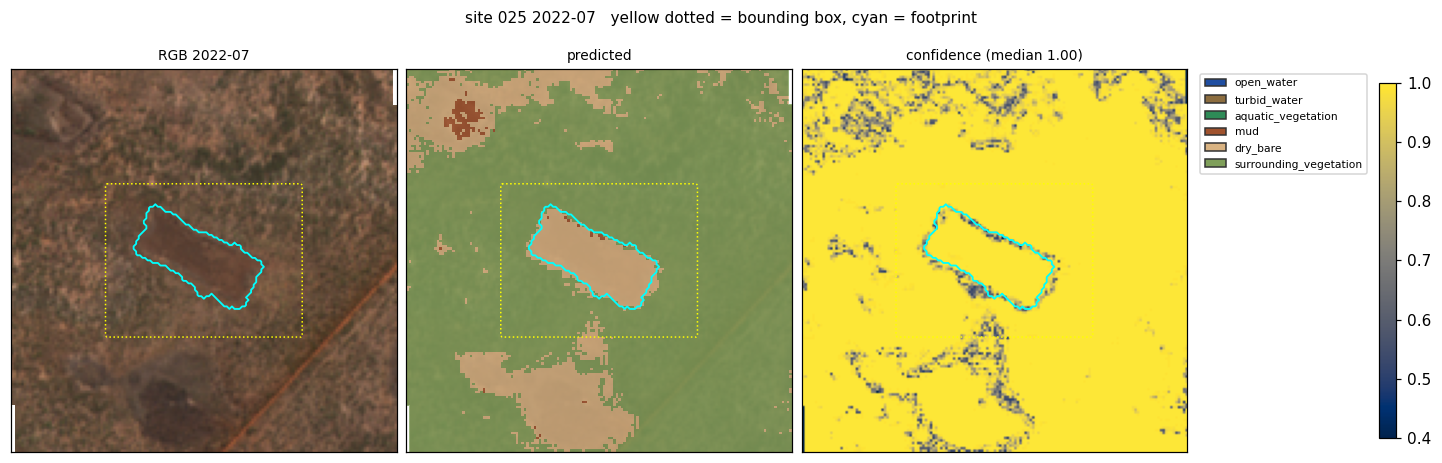

In [6]:
import rasterio
import wh_footprint
import wh_tiles

# A mid-confidence month, alongside its true colour and confidence.
sample = preview.sort_values("mean_confidence").iloc[len(preview) // 2]["year_month"]
row = manifest[(manifest["site_id"] == DRY_RUN_SITE)
               & (manifest["year_month"] == sample)].iloc[0]
tile = wh_tiles.read_tile(row["tif_path"], cfg)
stem = Path(row["tif_path"]).stem

with rasterio.open(wh_predict.raster_path(cfg, DRY_RUN_SITE, stem, "pred")) as src:
    classes = src.read(1)
with rasterio.open(wh_predict.raster_path(cfg, DRY_RUN_SITE, stem, "conf")) as src:
    confidence = src.read(1) / 100.0

# The two regions the composition is counted within.
box_mask = wh_bbox.load_mask(cfg, DRY_RUN_SITE)
try:
    footprint_mask = wh_footprint.load_mask(cfg, DRY_RUN_SITE)
except FileNotFoundError:
    footprint_mask = None
    print(f"site {DRY_RUN_SITE} has no footprint; only the bounding box is drawn")

figure, axes = plt.subplots(1, 3, figsize=(13, 4.4), constrained_layout=True)

axes[0].imshow(wh_plots.rgb_composite(tile))
axes[0].set_title(f"RGB {sample}", fontsize=9)

axes[1].imshow(wh_plots.rgb_composite(tile))
axes[1].imshow(wh_plots.class_overlay(classes, cfg, alpha=0.8), interpolation="nearest")
axes[1].set_title("predicted", fontsize=9)

image = axes[2].imshow(confidence, cmap="cividis", vmin=0.4, vmax=1.0)
plt.colorbar(image, ax=axes[2], fraction=0.046, pad=0.03)
axes[2].set_title(f"confidence (median {np.median(confidence):.2f})", fontsize=9)

# Yellow dotted = the labelled bounding box, cyan = the derived footprint.
# The bbox_* columns count within the yellow outline, footprint_* within the cyan.
for axis in axes:
    if box_mask.any():
        axis.contour(box_mask, levels=[0.5], colors="#ffff00",
                     linewidths=1.0, linestyles="dotted")
    if footprint_mask is not None and footprint_mask.any():
        axis.contour(footprint_mask, levels=[0.5], colors="#00ffff", linewidths=1.2)
    axis.set_xticks([]); axis.set_yticks([])

wh_plots.class_legend(axes[-1], cfg)
figure.suptitle(
    f"site {DRY_RUN_SITE} {sample}   "
    f"yellow dotted = bounding box, cyan = footprint", fontsize=10,
)
plt.show()

## Run the archive

Resumable — sites whose rasters already exist are skipped unless `overwrite=True`, so an
interrupted run picks up where it stopped. Roughly 65 minutes on 6 workers with confidence
rasters, or about 25 without.

In [2]:
table = wh_predict.run(manifest, cfg, PARAMS)
path = wh_predict.save_table(table, cfg)

print(f"\n{len(table):,} site-months -> {path}")
print(f"{table['site_id'].nunique()} sites, {table['year_month'].nunique()} months")
table.head(3)

NameError: name 'wh_predict' is not defined

## Sanity checks

Worth running before drawing any conclusions from the table.

In [ ]:
names = [d.name for d in cfg.classes if not d.ignore]
fractions = table[[f"bbox_frac_{n}" for n in names]].sum(axis=1, min_count=1)
classified = table["bbox_n_classified"] > 0

print(f"rows                          : {len(table):,}")
print(f"fractions sum to 1 where any  : "
      f"{bool(((fractions - 1).abs() < 1e-9)[classified].all())}")
print(f"site-months with no classified px: {int((~classified).sum())}")
print(f"sites with no footprint       : "
      f"{int((~table.groupby('site_id')['has_footprint'].any()).sum())}")
print(f"counts never exceed the region: "
      f"{bool((table['bbox_n_classified'] <= table['n_pixels_bbox']).all())}")
print(f"\ndata quality: {table['data_quality'].value_counts().to_dict()}")
print(f"isolated-wet flags: {int(table['flag_isolated_wet'].sum())}")

## Composition through time

The stacked area for one waterhole. Flagged months are marked with a star and months with no
classified pixels with a grey triangle — neither is removed, because a gap in the record is
information too.

In [ ]:
figure = wh_plots.plot_site_composition(table, DRY_RUN_SITE, cfg, PARAMS.denominator)
plt.show()

In [ ]:
# A few more, chosen to span the waterhole types in the box labels.
for site_id in table.drop_duplicates("site_id").head(4)["site_id"]:
    if site_id == DRY_RUN_SITE:
        continue
    figure = wh_plots.plot_site_composition(table, site_id, cfg, PARAMS.denominator)
    plt.show()

### Every site at once

Seasonality should read as vertical banding. A site that looks unlike its neighbours is
either genuinely different or one the model does not handle — the confidence panel below is
how to tell those apart.

In [ ]:
figure = wh_plots.plot_composition_heatmap(
    table, cfg, class_name="open_water", denominator=PARAMS.denominator
)
plt.show()

In [ ]:
figure = wh_plots.plot_composition_quality(table)
plt.show()

print("lowest-confidence sites — check these before trusting their series:")
print(table.groupby("site_id")["mean_confidence"].mean().nsmallest(8).round(3).to_string())

## Export the dashboard assets

The box polygons and the class scheme, as the files `dashboard_plan.md` expects.

In [ ]:
geojson_path = wh_predict.export_boxes_geojson(cfg, boxes)
colours_path = wh_predict.export_class_colours(cfg)

print(f"boxes   -> {geojson_path}")
print(f"colours -> {colours_path}")

total = sum(p.stat().st_size for p in
            (cfg.paths["predictions"] / "pixel_predictions").rglob("*"))
print(f"\npixel_predictions on disk: {total / 1e6:.0f} MB")
print("Small enough to serve as static files — no backend needed. See dashboard_plan.md.")